In [4]:

import random
random.seed(0)

import numpy as np
np.random.seed(0)

import tensorflow as tf
np.random.seed(0)

In [6]:

import os
import json
from zipfile import ZipFile
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow import keras
import cv2

In [8]:
kaggle_credentails = json.load(open("kaggle.json"))

In [9]:
os.environ['KAGGLE_USERNAME'] = kaggle_credentails["username"]
os.environ['KAGGLE_KEY'] = kaggle_credentails["key"]

In [10]:

!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)




  0%|          | 0.00/157M [00:00<?, ?B/s]
  1%|          | 1.00M/157M [00:04<11:53, 229kB/s]
  1%|▏         | 2.00M/157M [00:06<07:16, 373kB/s]
  2%|▏         | 3.00M/157M [00:06<04:39, 578kB/s]
  3%|▎         | 4.00M/157M [00:07<03:23, 789kB/s]
  3%|▎         | 5.00M/157M [00:08<03:07, 850kB/s]
  4%|▍         | 6.00M/157M [00:09<02:33, 1.03MB/s]
  4%|▍         | 7.00M/157M [00:10<02:35, 1.01MB/s]
  5%|▌         | 8.00M/157M [00:12<03:50, 678kB/s] 
  6%|▋         | 10.0M/157M [00:13<02:20, 1.10MB/s]
  7%|▋         | 11.0M/157M [00:14<02:41, 950kB/s] 
  8%|▊         | 12.0M/157M [00:15<02:24, 1.05MB/s]
  8%|▊         | 13.0M/157M [00:16<02:31, 995kB/s] 
  9%|▉         | 14.0M/157M [00:17<01:56, 1.29MB/s]
 10%|▉         | 15.0M/157M [00:17<01:37, 1.53MB/s]
 10%|█         | 16.0M/157M [00:18<01:37, 1.52MB/s]
 11%|█         | 17.0M/157M [00:18<01:38, 1.48MB/s]
 11%|█▏        | 18.0M/157M [00:19<01:17, 1.88MB/s]
 12%|█▏        | 19.0M/157M [00:19<01:11, 2.02MB/s]
 13%|█▎        | 20.0M/15

In [11]:

!ls

Brain_Tumor_Predicition.ipynb
brain-tumor-mri-dataset.zip
kaggle.json


In [12]:

with ZipFile('brain-tumor-mri-dataset.zip', 'r') as zipObj:
   # Extract all the contents of zip file in current directory
   zipObj.extractall()

In [13]:
# Basically , We have classes
# 1) Glioma
# 2) Meningioma
# 3) Pituitary
# 4) No Tumor

Text(0.5, 1.0, 'Glioma Sample Image')

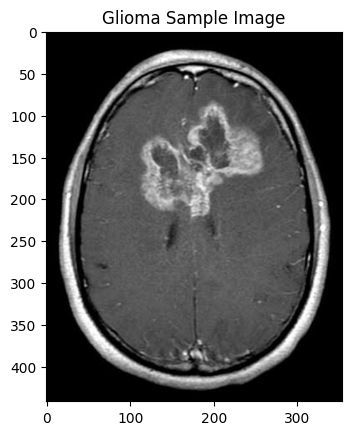

In [51]:
# 1) Glioma
data_dir = "Brain Tumor MRI Dataset"
image_path = os.path.join(data_dir, "Testing", "glioma", "Te-gl_1.jpg")
if not os.path.exists(image_path):
    if not os.path.exists(image_path):
        for root, dirs, files in os.walk("."):
            if "Te-gl_1.jpg" in files:
                image_path = os.path.join(root, "Te-gl_1.jpg")
                break
        else:
            raise FileNotFoundError(f"{image_path} not found. Check extracted dataset folder.")
image = plt.imread(image_path)
plt.imshow(image)
plt.imshow(image)
plt.title("Glioma Sample Image")

Text(0.5, 1.0, 'Maningioma Sample Image')

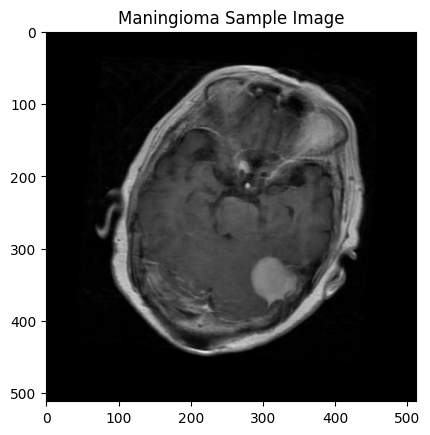

In [50]:

# 2) Meningioma
data_dir = "Brain Tumor MRI Dataset"
image_path = os.path.join(data_dir, "Testing", "meningioma", "Te-aug-me_1.jpg")
if not os.path.exists(image_path):
    if not os.path.exists(image_path):
        for root, dirs, files in os.walk("."):
            if "Te-aug-me_1.jpg" in files:
                image_path = os.path.join(root, "Te-aug-me_1.jpg")
                break
        else:
            raise FileNotFoundError(f"{image_path} not found. Check extracted dataset folder.")
image = plt.imread(image_path)
plt.imshow(image)
plt.imshow(image)
plt.title("Maningioma Sample Image")

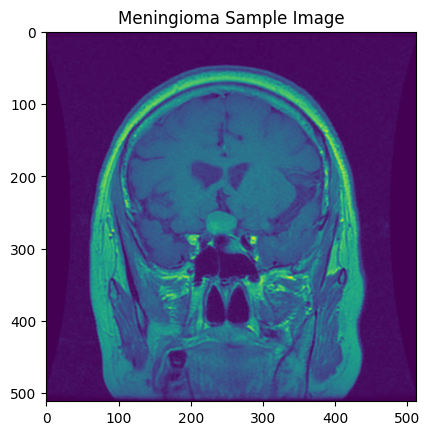

In [48]:
import os
import matplotlib.pyplot as plt

data_dir = "Brain Tumor MRI Dataset"
image_name = "Te-pi_1.jpg"

image_path = os.path.join(data_dir, "Testing", "meningioma", image_name)

# fallback search if not found
if not os.path.exists(image_path):
    for root, dirs, files in os.walk("."):
        if image_name in files:
            image_path = os.path.join(root, image_name)
            break
    else:
        raise FileNotFoundError(f"{image_name} not found in dataset")

# load image
image = plt.imread(image_path)

# display
plt.imshow(image)
plt.axis("on")
plt.title("Meningioma Sample Image")
plt.show()

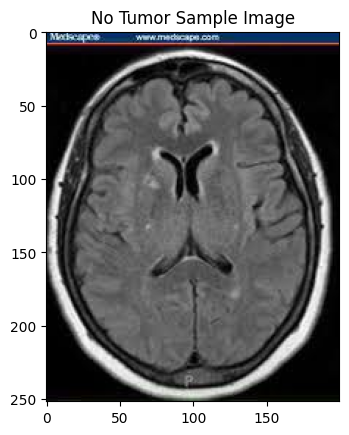

In [49]:
import os
import matplotlib.pyplot as plt

data_dir = "Brain Tumor MRI Dataset"
image_name = "Te-no_1.jpg"

image_path = os.path.join(data_dir, "Testing", "notumor", image_name)

# fallback search if not found
if not os.path.exists(image_path):
    for root, dirs, files in os.walk("."):
        if image_name in files:
            image_path = os.path.join(root, image_name)
            break
    else:
        raise FileNotFoundError(f"{image_name} not found in dataset")

# load + display image
image = plt.imread(image_path)

plt.imshow(image)
plt.axis("on")
plt.title("No Tumor Sample Image")
plt.show()

In [45]:
import os

data_dir = "/content"  # apna dataset root path yahan set karo

def get_classes(path):
    if not os.path.exists(path):
        for root, dirs, files in os.walk("."):
            if os.path.basename(root).lower() in ["training", "testing"]:
                path = root
                break
        else:
            raise FileNotFoundError(f"Folder not found: {path}")

    return [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]


train_path = os.path.join(data_dir, "Training")
test_path = os.path.join(data_dir, "Testing")

train_classes = get_classes(train_path)
test_classes = get_classes(test_path)

print("Training Classes:", train_classes)
print("Total Training Classes:", len(train_classes))

print("\nTesting Classes:", test_classes)
print("Total Testing Classes:", len(test_classes))

Training Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Total Training Classes: 4

Testing Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Total Testing Classes: 4


In [53]:

# Meanwhile Checking the total Number of images of Each player in the directory
total_images=0
print('Trianing Dataset ')
for i in Tumors:
    class_dir = os.path.join(org_dir, i)
    if not os.path.exists(class_dir):
        raise FileNotFoundError(f"Folder not found: {class_dir}")
    images = os.listdir(class_dir)
    total_images += len(images)
    print(f'Total Number of images of {i} are : {len(images)}')
print(f'Total Images in dataset is {total_images}')
print(f'Total Images in dataset is {total_images}')

Trianing Dataset 
Total Number of images of glioma are : 1400
Total Number of images of meningioma are : 1400
Total Number of images of notumor are : 1400
Total Number of images of pituitary are : 1400
Total Images in dataset is 5600
Total Images in dataset is 5600


In [59]:
# Meanwhile Checking the total Number of images of Each player in the directory
data_dir = "Brain Tumor MRI Dataset"
test_dir = os.path.join(data_dir, "Training")

# fallback if path not found
if not os.path.exists(test_dir):
    for root, dirs, files in os.walk("."):
        if os.path.basename(root).lower() == "testing":
            test_dir = root
            break
    else:
        raise FileNotFoundError("Testing folder not found")

total_images = 0

print("Testing Dataset Image Counts:\n")

for cls in os.listdir(test_dir):
    class_path = os.path.join(test_dir, cls)

    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        print(f"{cls}: {count} images")
        total_images += count

print("\nTotal Testing Images:", total_images)

Testing Dataset Image Counts:

glioma: 400 images
meningioma: 400 images
notumor: 400 images
pituitary: 400 images

Total Testing Images: 1600


In [72]:

  # Meanwhile Checking the total Number of images of Each player in the directory
  total_images=0
  print('Training Dataset ')
  for i in Tumors1:
    class_dir = os.path.join(data_dir, "Training", i)
    if not os.path.exists(class_dir):
      for root, dirs, files in os.walk("."):
        if os.path.basename(root).lower() == i.lower():
          class_dir = root
          break
      else:
        raise FileNotFoundError(f"Folder not found: {class_dir}")
    images = os.listdir(class_dir)
    total_images += len(images)
    print(f'Total Number of images of {i} are : {len(images)}')
  print(f'Total Images in dataset is {total_images}')
 

Training Dataset 
Total Number of images of glioma are : 400
Total Number of images of meningioma are : 400
Total Number of images of notumor are : 400
Total Number of images of pituitary are : 400
Total Images in dataset is 1600


In [73]:
Batch_size=64
img_height=224
img_width=224
     

In [74]:
data_gen_train=ImageDataGenerator(rescale=1./255,
                            validation_split=0.2,
                            rotation_range=40,
                            width_shift_range=0.2,
                            height_shift_range=0.2,
                            shear_range=0.2,
                            zoom_range=0.2,
                            horizontal_flip=True,
                            fill_mode='nearest'
                            )

In [80]:

train_data=data_gen_train.flow_from_directory(org_dir,
                                     target_size=(img_height,img_width),
                                     batch_size=Batch_size,
                                     class_mode='categorical',
                                     subset='training')

Found 4480 images belonging to 4 classes.


In [81]:
test_data=data_gen_train.flow_from_directory(org_dir,
                                     target_size=(img_height,img_width),
                                     batch_size=Batch_size,
                                     class_mode='categorical',
                                     subset='validation')

Found 1120 images belonging to 4 classes.


In [82]:

validation_data=data_gen_train.flow_from_directory(org_dir,
                                     target_size=(img_height,img_width),
                                     batch_size=Batch_size,
                                     class_mode='categorical',
                                     subset='validation')

Found 1120 images belonging to 4 classes.


In [83]:

train_data.class_indices

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

In [84]:

test_data.class_indices

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

In [85]:
# Convolutional Neural Network (CNN) Model for Brain Tumor Classification

# Model Definition
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(4, activation='softmax')  # 4 output classes (Glioma, Meningioma, Pituitary, No Tumor)
])

# Model Compilation
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


# Model Training
history = model.fit(
    train_data,
    epochs=10,  # You can adjust the number of epochs
    validation_data=validation_data
)

# Model Evaluation
train_loss, train_acc = model.evaluate(train_data)
print(f'Train accuracy: {train_acc}')

# Model Evaluation
test_loss, test_acc = model.evaluate(test_data)
print(f'Test accuracy: {test_acc}')


c:\Users\Lenovo\Brain_Tumor_Prediction\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 402s 6s/step - accuracy: 0.4652 - loss: 1.1962 - val_accuracy: 0.6045 - val_loss: 0.8973
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 299s 4s/step - accuracy: 0.6400 - loss: 0.8657 - val_accuracy: 0.6420 - val_loss: 0.8149
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 310s 4s/step - accuracy: 0.6685 - loss: 0.8001 - val_accuracy: 0.6768 - val_loss: 0.7910
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 359s 5s/step - accuracy: 0.6859 - loss: 0.7745 - val_accuracy: 0.6911 - val_loss: 0.7962
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 312s 4s/step - accuracy: 0.7205 - loss: 0.7100 - val_accuracy: 0.7063 - val_loss: 0.6942
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 303s 4s/step - accuracy: 0.7116 - loss: 0.7037 - val_accuracy: 0.6804 - val_loss: 0.7519
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 318s 5s/step - accuracy: 0.7225 - loss: 0.6800 - val_accuracy: 0.7295 - val_loss: 0.6742
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 319s 5s/step - accuracy: 0.7393 - loss: 0.6603 - val_accuracy: 0.7321 - v

In [86]:
# Using Transfer Learning with a pre-trained model (e.g., InceptionV3)
base_model = tf.keras.applications.InceptionV3(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

# Freeze the pre-trained layer
base_model.trainable = False

# Create a new model on top of the pre-trained model
model_transfer = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
     tf.keras.layers.Dropout(0.5),  # Add Dropout
    tf.keras.layers.Dense(4, activation='softmax')
])

# Compile the model
model_transfer.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model (only the top layers will be trained)
history_transfer = model_transfer.fit(
    train_data,
    epochs=10,
    validation_data=validation_data
)

# Evaluate the transfer learning model
train_loss_transfer, train_acc_transfer = model_transfer.evaluate(train_data)
print(f'Train accuracy (Transfer Learning): {train_acc_transfer}')

test_loss_transfer, test_acc_transfer = model_transfer.evaluate(test_data)
print(f'Test accuracy (Transfer Learning): {test_acc_transfer}')

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 55s 1us/step
Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 465s 6s/step - accuracy: 0.6730 - loss: 0.8365 - val_accuracy: 0.8170 - val_loss: 0.5274
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 440s 6s/step - accuracy: 0.7701 - loss: 0.6032 - val_accuracy: 0.8295 - val_loss: 0.4726
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 501s 7s/step - accuracy: 0.7911 - loss: 0.5494 - val_accuracy: 0.8509 - val_loss: 0.4183
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 496s 6s/step - accuracy: 0.8080 - loss: 0.5087 - val_accuracy: 0.8607 - val_loss: 0.3897
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 436s 6s/step - accuracy: 0.8136 - loss: 0.4995 - val_accuracy: 0.8580 - val_loss: 0.3980
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 429s 6s/step - accuracy: 0.8239 - loss: 0.4681 - val_accuracy: 0.8562 - val_loss: 0.3949
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 433s 6s/step - accuracy: 0.8214 - loss: 0.4659 - val_accuracy: 0.8438 - val_loss: 0.3992
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 427s 6s/step - accura

In [87]:

model.evaluate(test_data)

18/18 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.7196 - loss: 0.6580


[0.6579902768135071, 0.7196428775787354]

In [100]:
import cv2
import numpy as np
import os

image_path = input("Enter your image path: ")

if not os.path.exists(image_path):
    print("❌ Image path not found")
else:
    image = cv2.imread(image_path)

    image = cv2.resize(image, (224, 224))
    image = image / 255.0
    image = np.expand_dims(image, axis=0)

    prediction = model.predict(image)
    predicted_class = np.argmax(prediction)

    classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

    print("Predicted Class:", classes[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Predicted Class: glioma


In [109]:
model.save("brain_tumor_model.keras")

In [110]:
from tensorflow.keras.models import load_model
model = load_model("brain_tumor_model.keras")